<a href="https://colab.research.google.com/github/DanialBahrami/Flix_PPC/blob/main/Flix_PPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Main Problem Definition**

You are in the Data Science team at FlixBus. Your colleagues from the marketing department (specifically from the **PPC** (**P**ay **P**er **C**lick) team) came to you with a problem
The PPC team handles the PPC ads, which are: for example, when you search for something on Google, and then some advertised results show up before the *organic* ones. For these ads FlixBus pays only when someone clicks on the ad, hence the name.
To help them manage such ads, Google provides them with daily data about the performance of their ads. This data includes (all on a daily basis):
* **clicks**: the number of clicks on the ad.
* **impressions**: the number of times the ad showed up (whether it was clicked or not).
* **cost**: the total cost that we paid (to Google) for the ad. (in microcents: 1e-6 €)
* **conversions**: the number of purchases. (fractions are normal and expected)
* **conversion_value**: the total revenue (in €)
* **ad_position**: the median position of the ad when it showed up
* **ad_location**: a derived variable we calculate describing where the ad showed up on the search results page (the top 3 positions show up on the top of the page, and the rest are displayed on the side of the page) (also a median)

---
**The Problem**

Google is soon deprecating the "ad position" parameters and is not going to provide them. The PPC team depends on these parameters to understand competition, market behaviour, and our ads' performance.
They were wondering if we could use the rest of the performance metrics to predict the ad position; so, we can continue to use it after Google deprecates it.
They provided you with the daily performance data of a specific ad for about 13 months.


---
**The Task**

1. Build a solution to predict the ad position.
2. (Optional bonus) Which ad position is most efficient for us? Where efficiency is defined as **revenue/cost**.
(Don't forget to mention how much that efficiency is)



Background
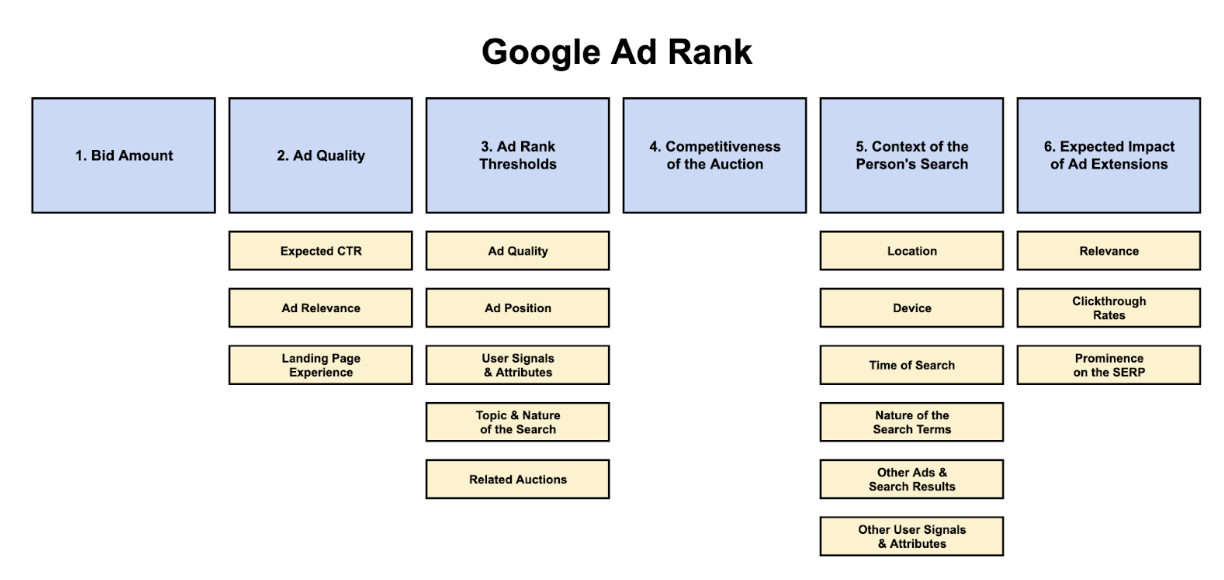

# **1- Exploratory Data Analysis**



In this section, we will perform an EDA to gain a deeper understanding of the dataset.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt

Taking into account that our dataset 'takehome_test_data.csv' is located within the Jupyter Notebook environment.

In [ ]:
# read data
df = pd.read_csv('takehome_test_data.csv', parse_dates = ['day'])
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   day               395 non-null    object 
 1   account           395 non-null    object 
 2   account_id        395 non-null    int64  
 3   campaign          395 non-null    object 
 4   campaign_id       395 non-null    int64  
 5   ad                395 non-null    object 
 6   ad_id             395 non-null    int64  
 7   clicks            395 non-null    int64  
 8   impressions       395 non-null    int64  
 9   cost              392 non-null    float64
 10  conversions       395 non-null    float64
 11  conversion_value  395 non-null    float64
 12  ad_position       395 non-null    object 
 13  ad_location       395 non-null    object 
dtypes: float64(3), int64(5), object(6)
memory usage: 43.3+ KB
None


,day,account,account_id,campaign,campaign_id,ad,ad_id,clicks,impressions,cost,conversions,conversion_value,ad_position,ad_location
0,2018-11-01,Google PPC Account,1312,Bus Campaign,156935,Munich - Berlin,1236985744,57,525,18030000.0,0.45,6.71,Fourth,Bottom of the page
1,2018-11-02,Google PPC Account,1312,Bus Campaign,156935,Munich - Berlin,1236985744,40,453,11300000.0,4.02,158.52,Third,Top of the page
2,2018-11-03,Google PPC Account,1312,Bus Campaign,156935,Munich - Berlin,1236985744,32,375,8640000.0,0.00,0.00,Third,Top of the page
3,2018-11-04,Google PPC Account,1312,Bus Campaign,156935,Munich - Berlin,1236985744,42,493,11790000.0,0.06,0.13,Fourth,Bottom of the page
4,2018-11-05,Google PPC Account,1312,Bus Campaign,156935,Munich - Berlin,1236985744,44,502,14060000.0,0.65,118.44,Third,Top of the page


In [ ]:
# make a copy of the original data
df_orginal = df.copy()

# Convert 'day' column to datetime format.
df['day'] = pd.to_datetime(df.day, errors='coerce')

Using ydata (pandas profiling) for quick feature analysis.

*https://github.com/ydataai/ydata-profiling*

In [ ]:
#using ydata (panda profiling) for feature analysis
!pip install ydata-profiling
IPython.display.clear_output()

In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Profiling Report")
profile_ts= ProfileReport(df, tsmode=True, title="Profiling Report - Time Series Sense")

In [ ]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile_ts

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

To begin, let's remove columns that contain only a single unique value, as they do not provide any meaningful insights. It is evident that the data is restricted to a single campaign.

In [ ]:
unique_counts = df.nunique()
single_value_columns = unique_counts[unique_counts == 1].index
print('to drop:', single_value_columns)
df.drop(single_value_columns, axis=1, inplace=True)
df.head()

to drop: Index(['account', 'account_id', 'campaign', 'campaign_id', 'ad', 'ad_id'], dtype='object')


,day,clicks,impressions,cost,conversions,conversion_value,ad_position,ad_location
0,2018-11-01,57,525,18030000.0,0.45,6.71,Fourth,Bottom of the page
1,2018-11-02,40,453,11300000.0,4.02,158.52,Third,Top of the page
2,2018-11-03,32,375,8640000.0,0.00,0.00,Third,Top of the page
3,2018-11-04,42,493,11790000.0,0.06,0.13,Fourth,Bottom of the page
4,2018-11-05,44,502,14060000.0,0.65,118.44,Third,Top of the page


Handle categorical variables by applying OneHotEncoder to *ad_location* and use Ordinal Mapping for *ad_position*.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
df_ohe = ohe.fit_transform(df[['ad_location']])
feature_names = ohe.get_feature_names_out(['ad_location'])
feature_names = ['Bottom', 'Top']
df_ohe = pd.DataFrame(df_ohe.toarray(), columns=feature_names)
df_proc = pd.concat([df.drop('ad_location', axis=1), df_ohe], axis=1)

ranks = [df_proc['ad_position'].unique()]
mapping = {'First':1, 'Second':2, 'Third':3, 'Fourth':4, 'Fifth':5}
df_proc['ad_position'] = df_proc['ad_position'].map(mapping)

df_proc.head()

,day,clicks,impressions,cost,conversions,conversion_value,ad_position,Bottom,Top
0,2018-11-01,57,525,18030000.0,0.45,6.71,4,1.0,0.0
1,2018-11-02,40,453,11300000.0,4.02,158.52,3,0.0,1.0
2,2018-11-03,32,375,8640000.0,0.00,0.00,3,0.0,1.0
3,2018-11-04,42,493,11790000.0,0.06,0.13,4,1.0,0.0
4,2018-11-05,44,502,14060000.0,0.65,118.44,3,0.0,1.0


Let's check for and remove any missing values in the dataset. However, please note that for the prediction part, I may want to consider using an imputer to handle missing values

In [ ]:
print(df_proc.isna().sum())
df_proc.dropna(inplace=True)

day                 1
clicks              0
impressions         0
cost                3
conversions         0
conversion_value    0
ad_position         0
Bottom              0
Top                 0
dtype: int64


Convert ***cost*** from microcent to euros

In [ ]:
df_proc['cost'] = df_proc['cost']/1000000

Negative values in the impression column do not hold any meaningful information. Therefore, it is necessary to replace these negative values.

In [ ]:
# Count negative values in each column
negative_counts = (df_proc.drop(columns=['day']) < 0).sum()
print(negative_counts)
print(df_proc[df_proc.impressions<0])

# replace with absolute value
df_proc['impressions'] = df_proc['impressions'].abs()

clicks              0
impressions         3
cost                0
conversions         0
conversion_value    0
ad_position         0
Bottom              0
Top                 0
dtype: int64
           day  clicks  impressions   cost  conversions  conversion_value  \
159 2019-05-09      79         -628  79.95         2.89            106.50   
346 2019-11-13      82         -723  36.08         1.43             58.49   
349 2019-11-16      77         -608  31.93         0.36              7.43   

     ad_position  Bottom  Top  
159            2     0.0  1.0  
346            4     1.0  0.0  
349            4     1.0  0.0  


Improving data by incorporating derived metrics that are relevant to the current problem at hand.


> **Actual Cost Per Click (CPC)** = cost/clicks

> **Conversion Rate (CR)** = conversions/clicks

> **Clickthrough rate (CTR)** = clicks/impressions


In [ ]:
df_proc['CTR'] = df_proc['clicks']/df_proc['impressions']
df_proc['CR'] = df_proc['conversions']/df_proc['clicks']
df_proc['CPC'] = df_proc['cost']/df_proc['clicks']

In [ ]:
df_proc.head()

,day,clicks,impressions,cost,conversions,conversion_value,ad_position,Bottom,Top,CTR,CR,CPC
0,2018-11-01,57,525,18.03,0.45,6.71,4,1.0,0.0,0.108571,0.007895,0.316316
1,2018-11-02,40,453,11.30,4.02,158.52,3,0.0,1.0,0.088300,0.100500,0.282500
2,2018-11-03,32,375,8.64,0.00,0.00,3,0.0,1.0,0.085333,0.000000,0.270000
3,2018-11-04,42,493,11.79,0.06,0.13,4,1.0,0.0,0.085193,0.001429,0.280714
4,2018-11-05,44,502,14.06,0.65,118.44,3,0.0,1.0,0.087649,0.014773,0.319545


Considering the influence of time, analyzing trends over time can be beneficial, especially since the Google Ad Rank algorithm incorporates time as one of its inputs. This analysis may aid us in making accurate predictions.

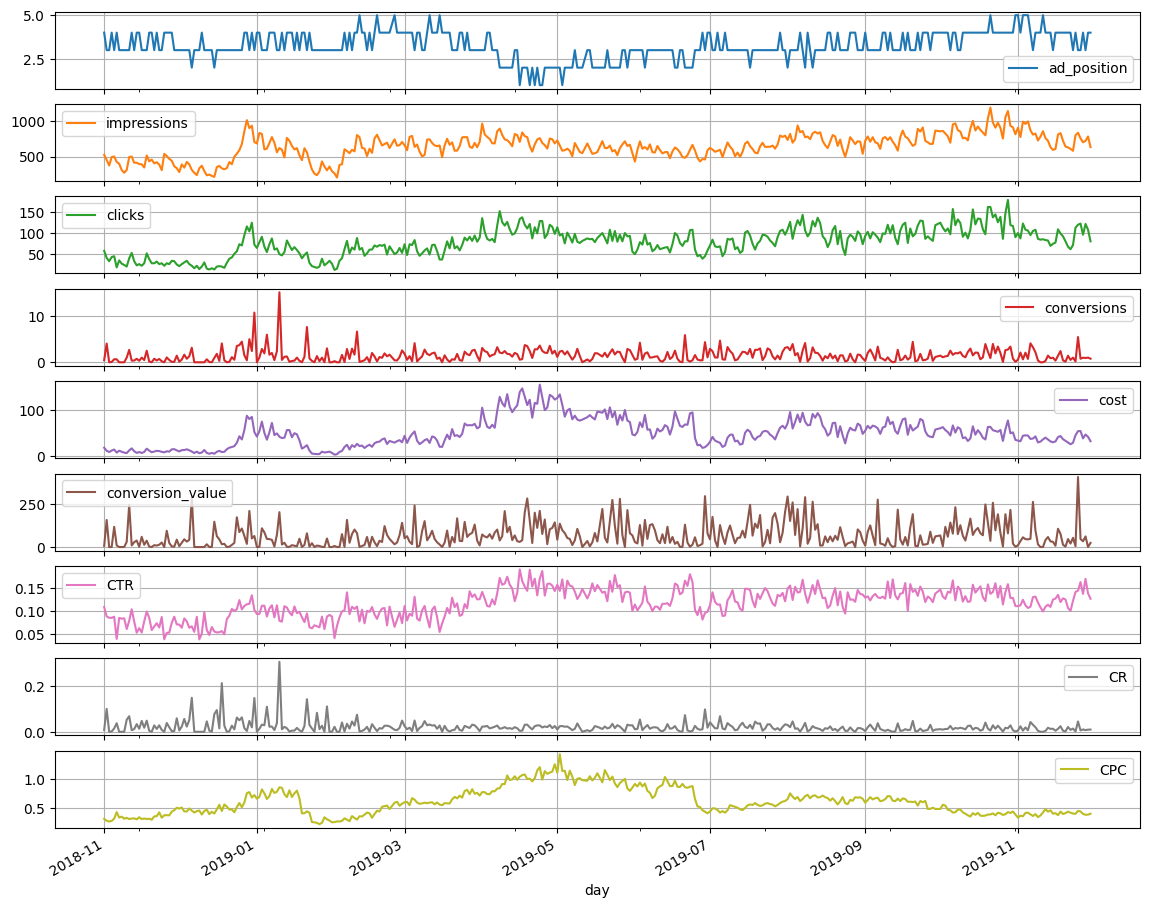

In [ ]:
mpl.rcParams['figure.figsize'] = (14, 12)
mpl.rcParams['axes.grid'] = True

plot_cols = ['ad_position', 'impressions', 'clicks', 'conversions', 'cost', 'conversion_value', 'CTR', 'CR', 'CPC']

plot_features = df_proc[plot_cols]
plot_features.index = df_proc['day']
_ = plot_features.plot(subplots=True)

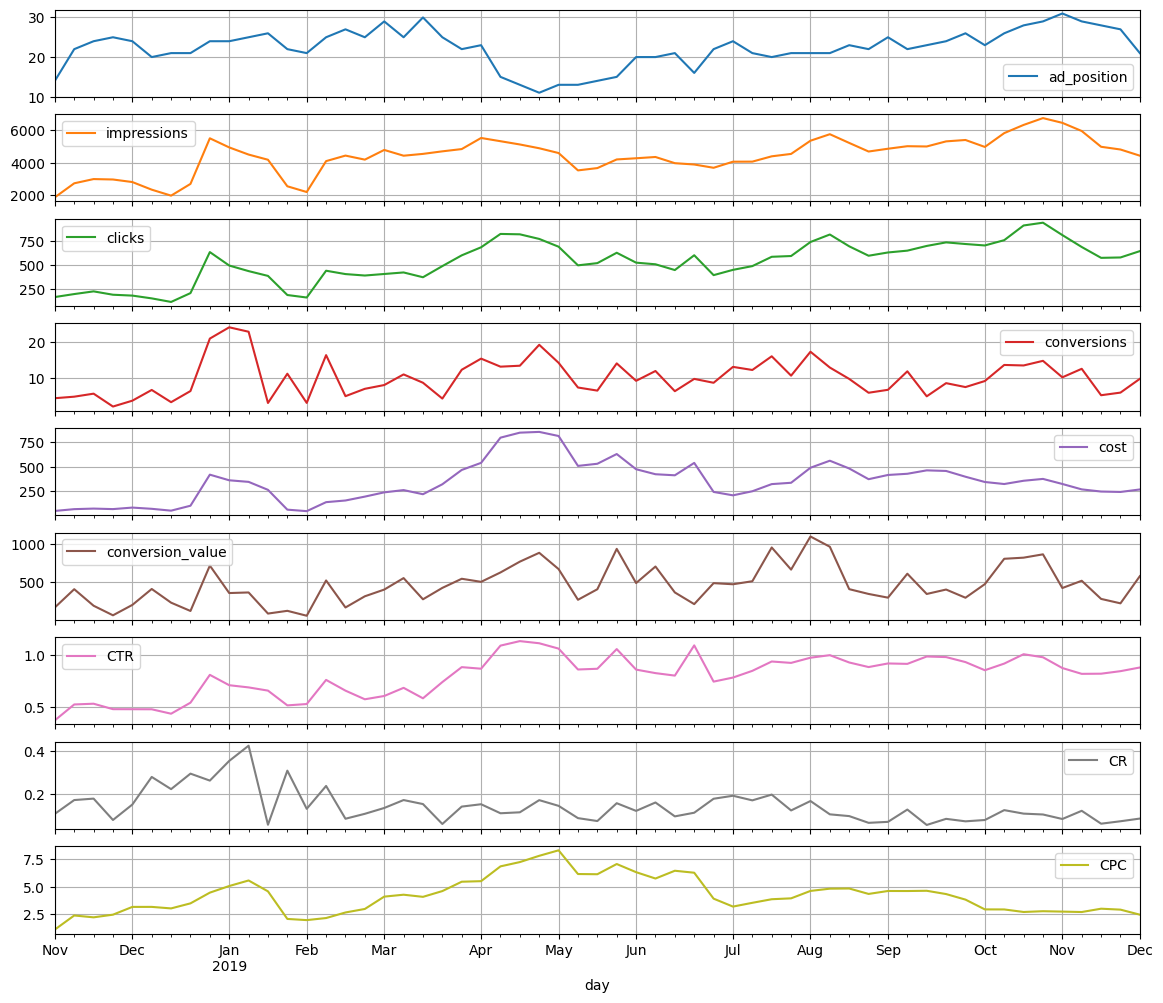

In [ ]:
# Aggregate the data on a weekly basis
df_weekly = df_proc.resample('W', on='day').sum()  # Resample to weekly frequency and sum the values

plot_features = df_weekly[plot_cols]
plot_features.index = df_weekly.index
_ = plot_features.plot(subplots=True)

Checking Seasonality

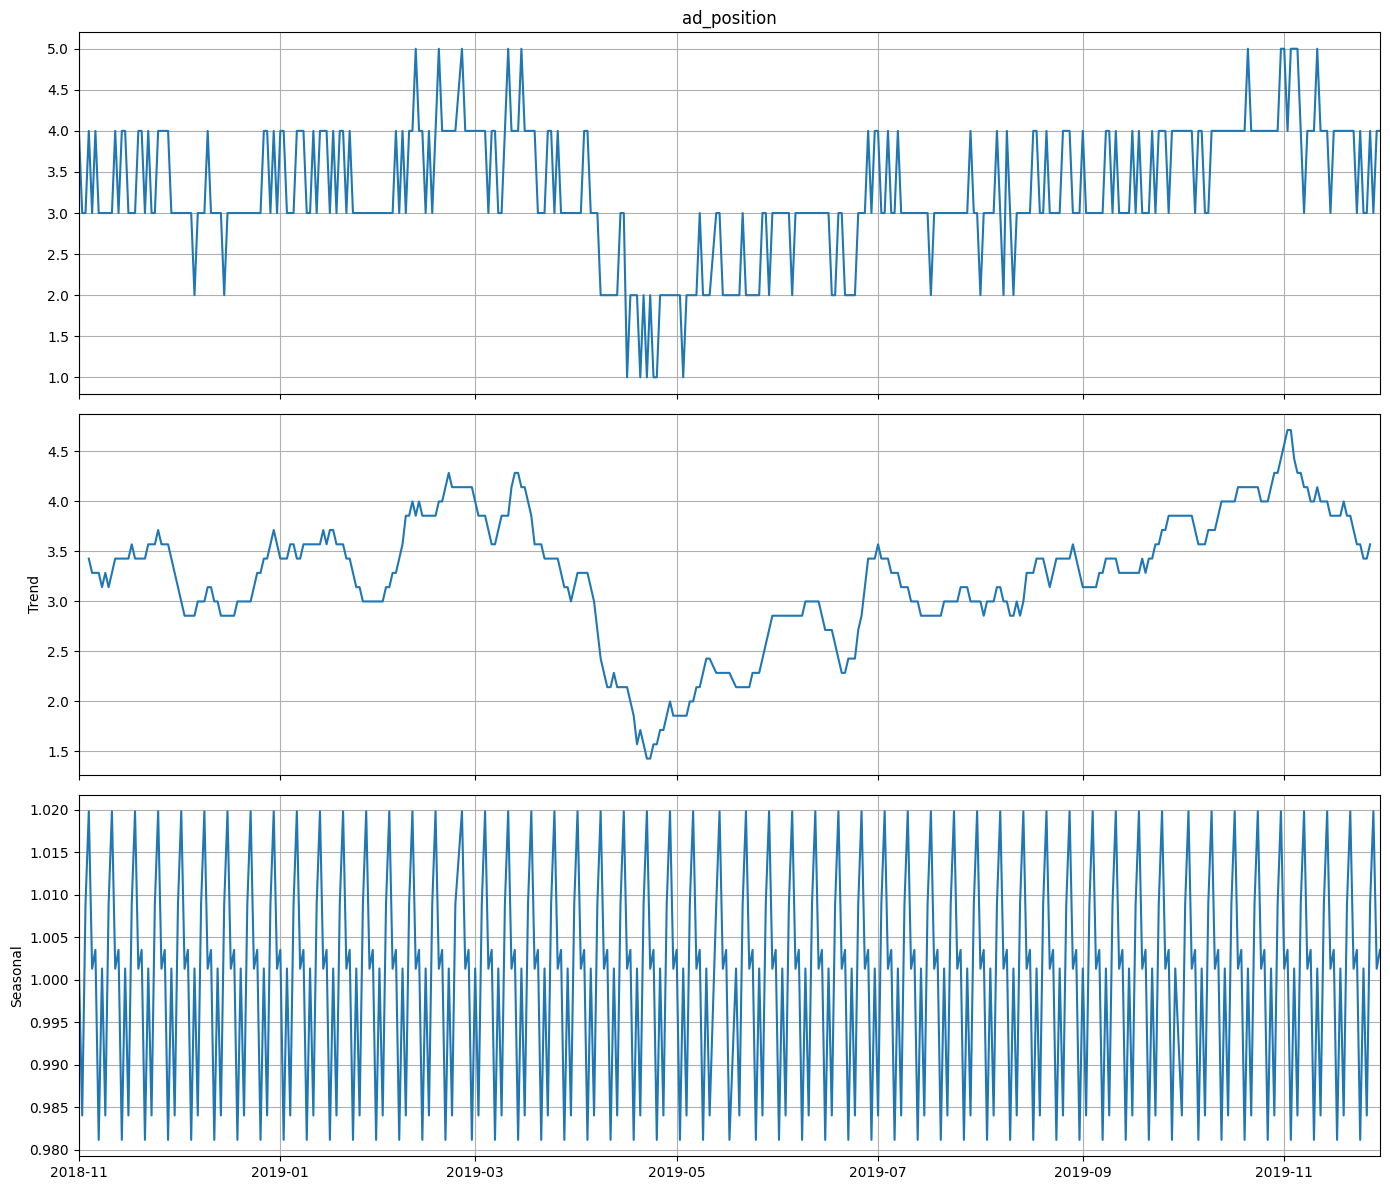

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
df_trend = df_proc.copy()
df_trend['day'] = pd.to_datetime(df_trend['day'])
df_trend.set_index('day', inplace=True)
df_trend.sort_index(inplace=True)
decompose_result_mult = seasonal_decompose(df_trend.ad_position.interpolate(),
                                           period=7,
                                           model="multiplicative")

decompose_result_mult.plot(
    observed=True, seasonal=True, trend=True, resid=False, weights=False
)
plt.show()

In [ ]:
df_proc['weekday'] = df_proc['day'].dt.weekday
# df_proc['month'] = df_proc['day'].dt.month    """not used, dataset contais just one year data, it may not generalize well to future data"""
df_proc.head()

,day,clicks,impressions,cost,conversions,conversion_value,ad_position,Bottom,Top,CTR,CR,CPC,weekday
0,2018-11-01,57,525,18.03,0.45,6.71,4,1.0,0.0,0.108571,0.007895,0.316316,3
1,2018-11-02,40,453,11.30,4.02,158.52,3,0.0,1.0,0.088300,0.100500,0.282500,4
2,2018-11-03,32,375,8.64,0.00,0.00,3,0.0,1.0,0.085333,0.000000,0.270000,5
3,2018-11-04,42,493,11.79,0.06,0.13,4,1.0,0.0,0.085193,0.001429,0.280714,6
4,2018-11-05,44,502,14.06,0.65,118.44,3,0.0,1.0,0.087649,0.014773,0.319545,0


To identify outliers, two different methods were employed. Firstly, a box plot was used to examine the range of each column, followed by the calculation of the interquartile range (IQR) to identify suspicious points. Secondly, an isolation forest model was applied to detect outliers. Additionally, a T-SNE visualization was used to gain a better understanding of the candidate outlier points.

In [ ]:
def check_outliers_boxplot(df):
  mean = df.mean()
  std = df.std()
  df_scaled = (df - mean) / std
  df_melt = df_scaled.melt(var_name='Column', value_name='Value')
  plt.figure(figsize=(df.shape[1], 6))
  # ax = sns.violinplot(x='Column', y='Value', data=df_melt)
  ax = sns.boxplot(x='Column', y='Value', data=df_melt)
  _ = ax.set_xticklabels(df.keys(), rotation=90)

# Inter Quantile Range
def IQR(df, column):
  # IQR
  # Calculate the upper and lower limits
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  indexes = df.loc[(df[column]<=lower) | (df[column]>= upper)].index

  return np.array(indexes)

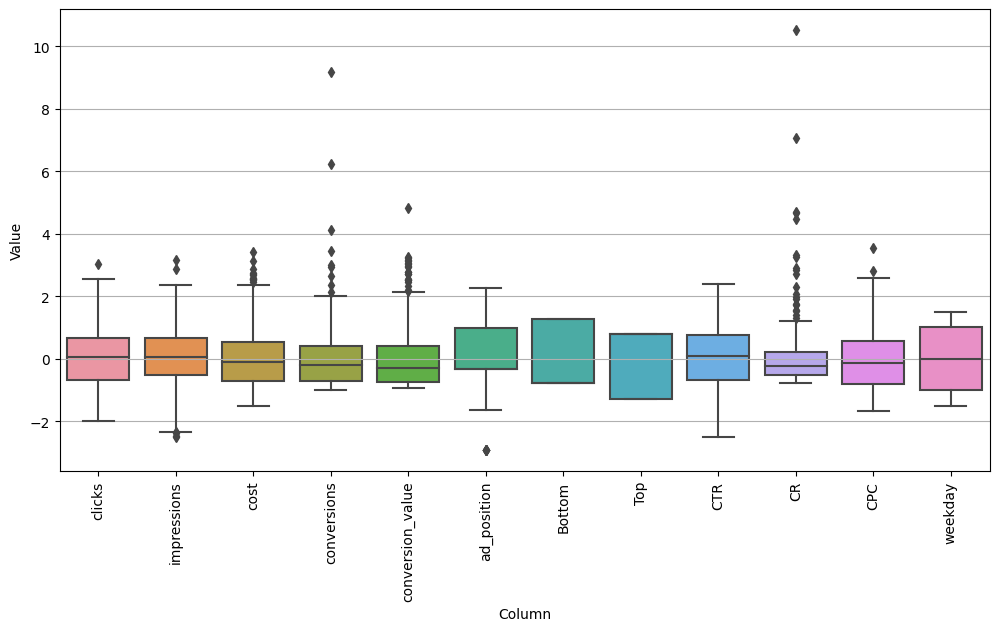

In [ ]:
check_outliers_boxplot(df_proc.drop(columns=['day']))

In [ ]:
outliers = [index for c in df_proc.columns if c != 'day' for index in IQR(df_proc, c)]
unique_outliers = np.unique(outliers)
outlier_rows = df_proc.loc[unique_outliers]
print(len(outlier_rows))
outlier_rows.head()

58


,day,clicks,impressions,cost,conversions,conversion_value,ad_position,Bottom,Top,CTR,CR,CPC,weekday
1,2018-11-02,40,453,11.30,4.02,158.52,3,0.0,1.0,0.088300,0.100500,0.282500,4
8,2018-11-11,39,494,12.17,2.66,247.50,3,0.0,1.0,0.078947,0.068205,0.312051,6
18,2018-11-30,24,337,12.20,1.42,43.53,3,0.0,1.0,0.071217,0.059167,0.508333,4
20,2018-12-03,29,345,12.92,1.63,45.49,3,0.0,1.0,0.084058,0.056207,0.445517,0
23,2018-12-06,21,314,9.64,3.13,289.19,2,0.0,1.0,0.066879,0.149048,0.459048,3


In [ ]:
from sklearn.ensemble import IsolationForest

iforest = IsolationForest(contamination='auto')
iforest.fit(df_proc.drop(columns=['day']))
scores = iforest.decision_function(df_proc.drop(columns=['day']))
anomalies = iforest.predict(df_proc.drop(columns=['day']))

# Create a new column 'anomaly' in the input data
df_anomaly = df_proc.copy()
df_anomaly['anomaly'] = anomalies

In [ ]:
abnormal_count = df_anomaly['anomaly'].value_counts()[-1]
print(abnormal_count)

69


In [ ]:
#t-SNE visualization
from sklearn.manifold import TSNE
tsne = TSNE()
tsne_features = tsne.fit_transform(df_proc.drop(columns=['day']))

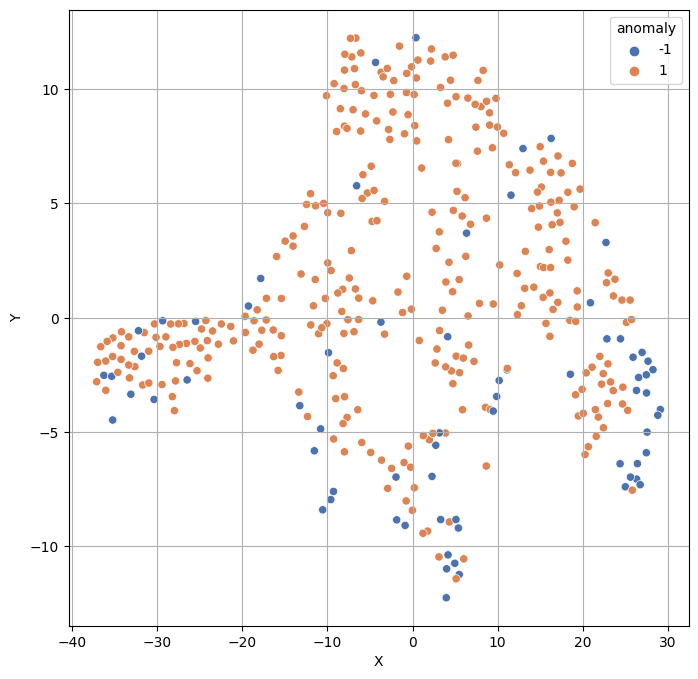

In [ ]:
df_tsne = df_anomaly.copy()
df_tsne['X'] = tsne_features[:, 0]
df_tsne['Y'] = tsne_features[:, 1]
palette = 'deep'
mpl.rcParams['figure.figsize'] = (8, 8)
sns.scatterplot(data=df_tsne, x="X", y="Y", hue="anomaly", palette=palette)
plt.show()

The identified outliers were not removed as they do not appear to be abnormal or irrelevant in the context of the problem.

**Cheking Multicollinearity**

When two or more variables are highly correlated, they carry almost the same information, making it redundant to include all of them in a model.

<ipython-input-40-cbe8d8b6dc4d>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df_proc.corr()


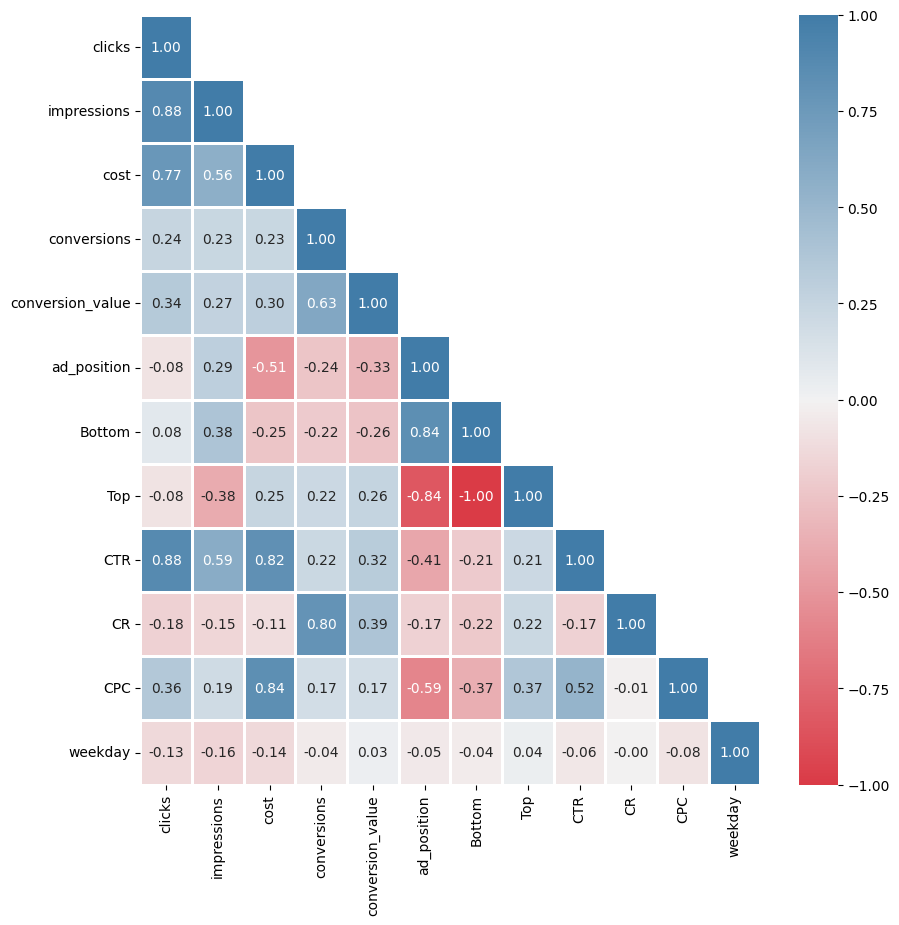

In [ ]:
corr = df_proc.corr()
mpl.rcParams['figure.figsize'] = (10, 10)
mpl.rcParams['axes.grid'] = False

cmap = sns.diverging_palette(h_neg=10, h_pos=240, as_cmap=True)
# sns.heatmap(corr, cmap=cmap, center=0, linewidths=1, annot=True, fmt=".2f")

mask = np.tril(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, cmap=cmap, mask=~mask, center=0, linewidths=1, annot=True, fmt=".2f")
plt.show()

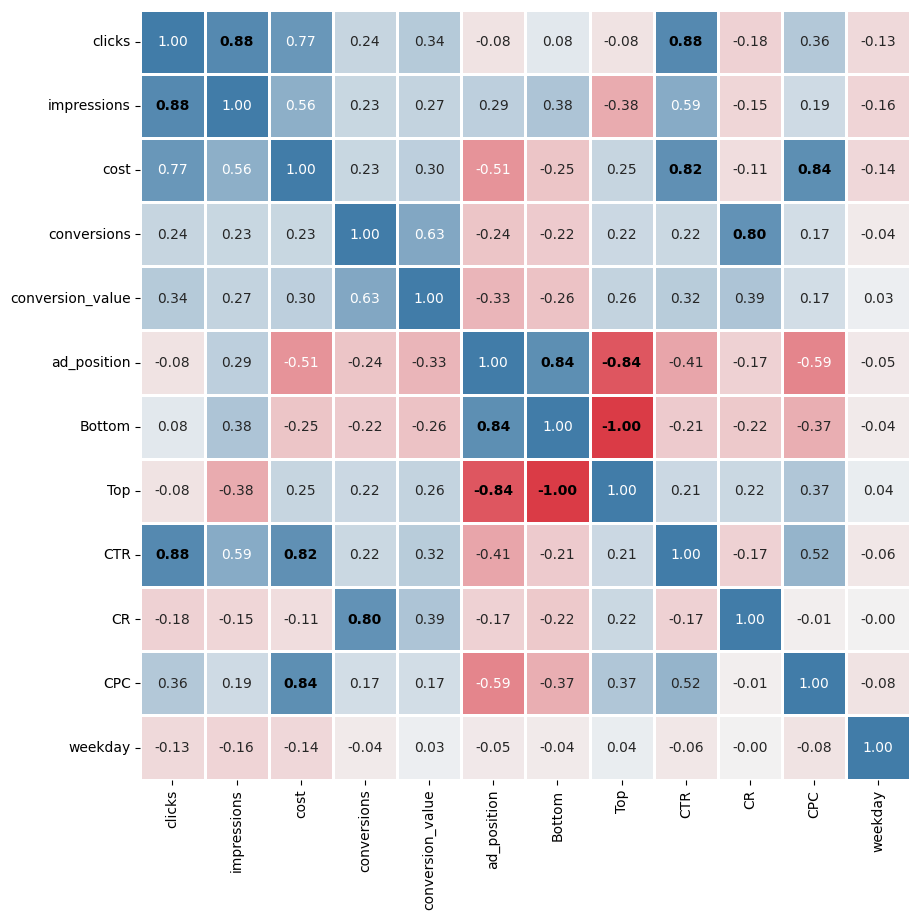

In [ ]:
# Highlight correlations greater than 0.8
mask = (corr.abs() > 0.8) & (corr.abs() < 1.0)
sns.heatmap(corr, cmap=cmap, center=0, linewidths=1, annot=True, fmt=".2f", mask=~mask, cbar=False, square=True, annot_kws={"weight": "bold",'color': 'black'})

sns.heatmap(corr, cmap=cmap, center=0, linewidths=1, annot=True, fmt=".2f", mask=mask, cbar=False)

plt.show()

# **2- Position Efficiency**



Before proceeding to the prediction problem, it is indeed possible to calculate the efficiency based on ad position and assess the effectiveness of each position. By analyzing the relationship between ad position and relevant metrics, we can gain insights into the performance of different positions and determine which positions yield the highest effectiveness. This analysis can provide valuable information for optimizing ad placements and improving overall advertising strategy.

In [ ]:
import plotly.express as px
df_proc['ROAS'] = df_proc['conversion_value']/df_proc['cost']

fig = px.box(df_proc,
             x="ROAS",
             color="ad_position",
             title="Efficiency", )
fig.update_traces(quartilemethod="exclusive")
fig.show()

In [ ]:
df_eff = df_proc.groupby(['ad_position']).agg({'conversion_value':'sum', 'cost':'sum'})
df_eff['ROI'] = df_eff['conversion_value']/df_eff['cost']
df_eff.style.bar(subset=['ROI'], color='green')

,conversion_value,cost,ROI
ad_position,,,
1,771.600000,777.860000,0.991952
2,5715.970000,4639.150000,1.232116
3,13303.770000,8266.580000,1.609344
4,6215.270000,5567.610000,1.116326
5,293.990000,434.240000,0.677022


<Axes: xlabel='ad_position'>

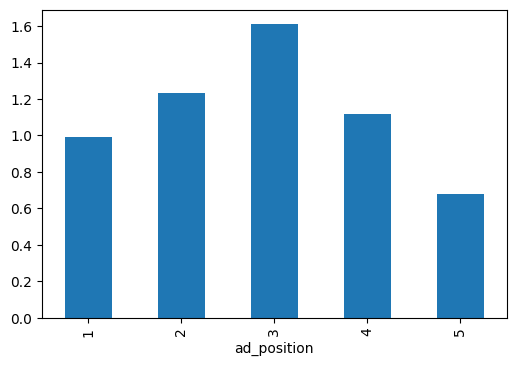

In [ ]:
mpl.rcParams['figure.figsize'] = (6, 4)
mpl.rcParams['axes.grid'] = False
df_eff['ROI'].plot.bar()

# **3- Ad Rank Prediction**


Let's consolidate all the necessary steps from the EDA section into a single preprocess function. This function will handle the data preprocessing tasks.

In [ ]:
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score

def read_data(path):
  df = pd.read_csv(path, parse_dates = ['day'])
  return df

def preprocess_data(df):
  df['day'] = pd.to_datetime(df.day, errors='coerce')
  df.dropna(subset=['day'], inplace=True)

  df.drop(columns=['account', 'account_id', 'campaign', 'campaign_id', 'ad',
                   'ad_id', 'ad_location'], axis=1, inplace=True)

  mapping = {'First':1, 'Second':2, 'Third':3, 'Fourth':4, 'Fifth':5}
  df['ad_position'] = df['ad_position'].map(mapping)

  imputer = SimpleImputer(strategy='mean')
  df['cost'] = imputer.fit_transform(df[['cost']])

  df['weekday'] = df['day'].dt.weekday
  df['cost'] = df['cost']/1000000
  df['impressions']= df['impressions'].abs()
  df['CTR'] = df['clicks']/df['impressions']
  df['CR'] = df['conversions']/df['clicks']
  df['CPC'] = df['cost']/df['clicks']
  df.drop(columns=['day'], inplace=True)

  return df

df = read_data('takehome_test_data.csv')
df = preprocess_data(df)

X = df.drop(columns=['ad_position'])
y = df['ad_position']

# Column Encoder for xgb classifier
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

First, let's examine the distribution of classes and determine if the samples are balanced or not.

Value Counts:
3    189
4    137
2     50
5     12
1      6
Name: ad_position, dtype: int64

Percentages:
3    47.969543
4    34.771574
2    12.690355
5     3.045685
1     1.522843
Name: ad_position, dtype: float64


Text(0.5, 1.0, 'Distribution of Ad Positions')

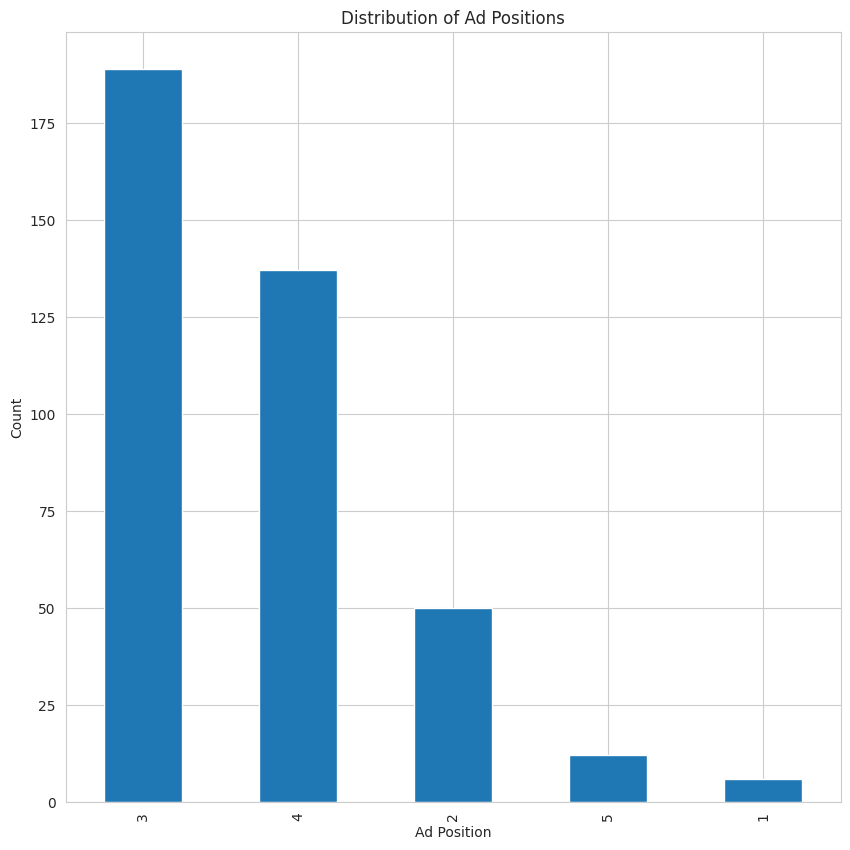

In [ ]:
value_counts = df['ad_position'].value_counts()
percentages = value_counts / len(df) * 100

# Print the value counts and percentages
print("Value Counts:")
print(value_counts)
print("\nPercentages:")
print(percentages)

# Plot a bar chart
ax = value_counts.plot.bar()
ax.set_xlabel('Ad Position')
ax.set_ylabel('Count')
ax.set_title('Distribution of Ad Positions')

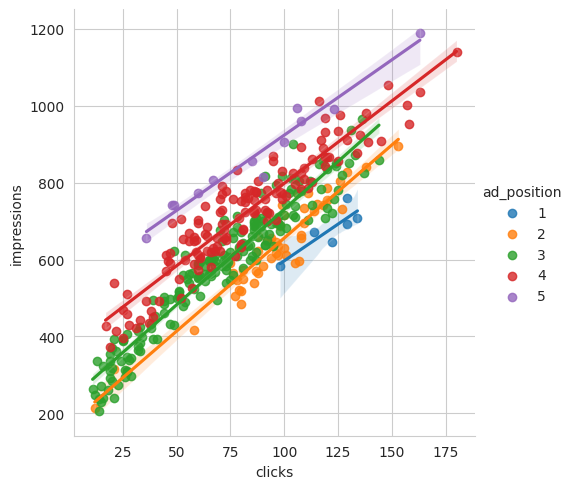

In [ ]:
sns.set_style('whitegrid')
sns.lmplot(x='clicks', y ='impressions', hue = 'ad_position', data =df )

<Axes: xlabel='clicks', ylabel='impressions'>

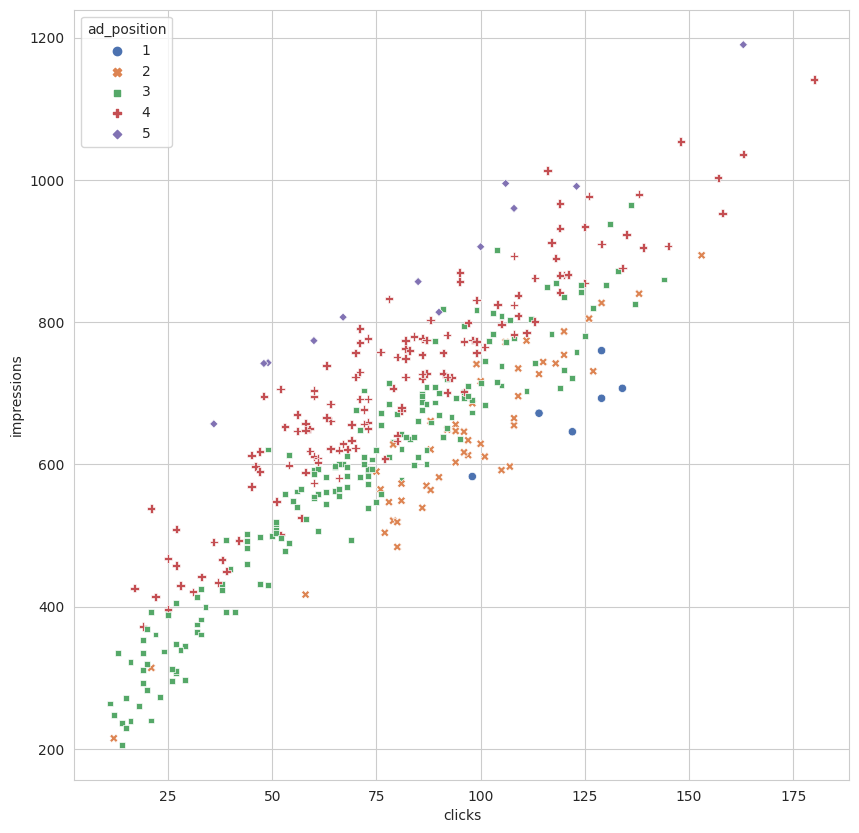

In [ ]:
sns.scatterplot(x='clicks', y ='impressions', hue = 'ad_position', data =df , palette="deep", style = 'ad_position')

Our dataset exhibits an **imbalance** issue, with nearly 50% of the samples belonging to the 3rd position. To address this challenge, we can explore two approaches:


*   **Data Approach:** We can employ Over/Under Sampling methods to tackle the class imbalance. Over-sampling involves randomly duplicating instances from the minority class, while under-sampling entails randomly removing instances from the majority class. These techniques aim to balance the class distribution and provide more representative training data


*  **Model Approach:** Another strategy is to utilize a weighted model that assigns higher weights to the minority classes during the training process. By doing so, the model focuses more on learning from the minority class samples and can improve its ability to classify them accurately.


Furthermore, we can consider a hybrid approach by combining both data and model techniques. This approach can potentially yield better results by leveraging the strengths of both methods and mitigating the impact of class imbalance effectively.

**Another important point to consider:**

Since the labels are crisp and discrete, we can view it as a multi-class classification problem. However, it's important to note that the ad_position is inherently ordinal. Classification methods treat classes independently, meaning that misclassifying rank 1 and rank 5 would result in the same error as misclassifying rank 1 and rank 2.

Further Readings:

https://analyticsindiamag.com/a-complete-tutorial-on-ordinal-regression-in-python/
https://www.cs.waikato.ac.nz/~eibe/pubs/ordinal_tech_report.pdf


To address this issue, we can adopt an **ordinal regression/ordinal classification approach**.
https://www.statsmodels.org/dev/examples/notebooks/generated/ordinal_regression.html

https://github.com/Shopify/bevel

https://pythonhosted.org/mord/


Alternatively, we can utilize regression methods and incorporate a post-processing step to translate the continuous output into discrete classes.

I will utilize standard regression methods as the initial approach, followed by implementing a post-processing step. Additionally, to address the issue of class imbalance, I will conduct experiments by comparing the performance of the models with and without applying **oversampling** techniques.

**1- XGboost Regressor + Imbalanced dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [ ]:
from sklearn.model_selection import cross_val_score, RepeatedKFold

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [5, 7],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1],
    'lambda': [1],
    'alpha' :[0, 0.001, 0.01]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, cv=3)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Build and train the XGBoost regressor model
xgb_reg = xgb.XGBRegressor(**best_params)
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(xgb_reg, X_train, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)

scores = np.absolute(scores)
print('Mean MAE: %.3f (%.3f)' % (scores.mean(), scores.std()) )

Mean MAE: 0.125 (0.033)


In [ ]:
xgb_reg.fit(X_train, y_train)

# Predict ad positions for test data
y_pred = xgb_reg.predict(X_test)

# Round the predictions to the nearest integer (ad position)
y_pred_rounded = [int(round(pred)) for pred in y_pred]

# Calculate accuracy of the model
accuracy = accuracy_score(y_test, y_pred_rounded)
print("Accuracy:", accuracy)

Accuracy: 0.773109243697479


Due to sample imbalance, accuracy alone does not provide a comprehensive reflection of the model's performance. Therefore, it is crucial to consider the confusion matrix and related evaluation measures to gain a more accurate assessment of the model's performance.

F1-score can be interpreted as a weighted average or harmonic mean of precision and recall, where the relative contribution of precision and recall to the F1-score are equal. F1-score reaches its best value at 1
 and worst score at 0.

What we are trying to achieve with the F1-score metric is to find an equal balance between precision and recall, which is extremely useful in most scenarios when we are working with imbalanced datasets.

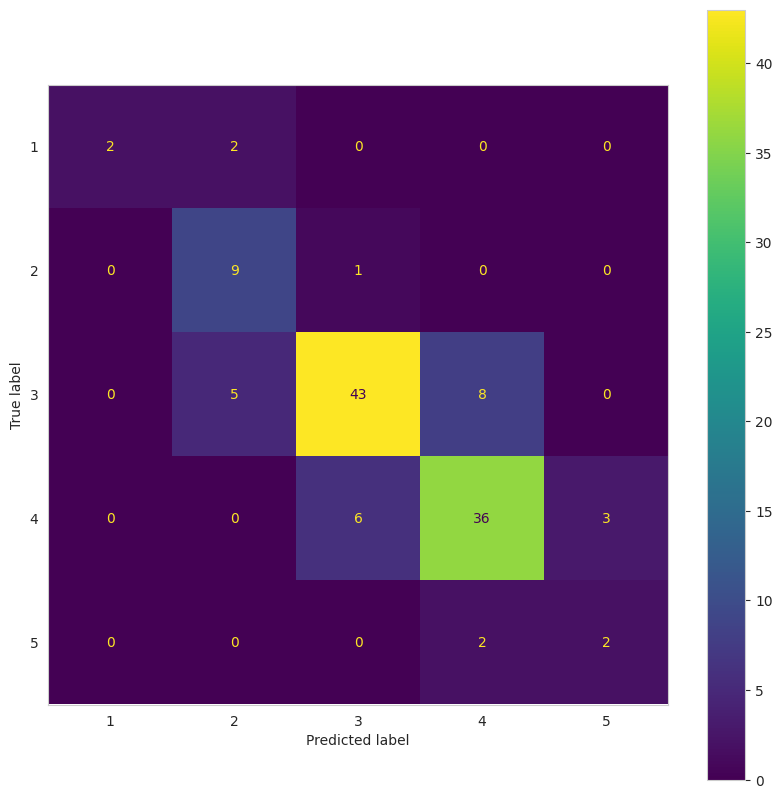

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_rounded)
disp = ConfusionMatrixDisplay(cm, display_labels = ['1', '2', '3', '4', '5'])
disp.plot()
mpl.rcParams.update({})
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_rounded))

print('f1 score for each class', f1_score(y_test, y_pred_rounded, average=None))
print('macro', f1_score(y_test, y_pred_rounded, average='macro'))
print('weighted', f1_score(y_test, y_pred_rounded, average='weighted'))

              precision    recall  f1-score   support

           1       1.00      0.50      0.67         4
           2       0.56      0.90      0.69        10
           3       0.86      0.77      0.81        56
           4       0.78      0.80      0.79        45
           5       0.40      0.50      0.44         4

    accuracy                           0.77       119
   macro avg       0.72      0.69      0.68       119
weighted avg       0.79      0.77      0.78       119

f1 score for each class [0.66666667 0.69230769 0.81132075 0.79120879 0.44444444]
macro 0.6811896698689152
weighted 0.7765199935804027


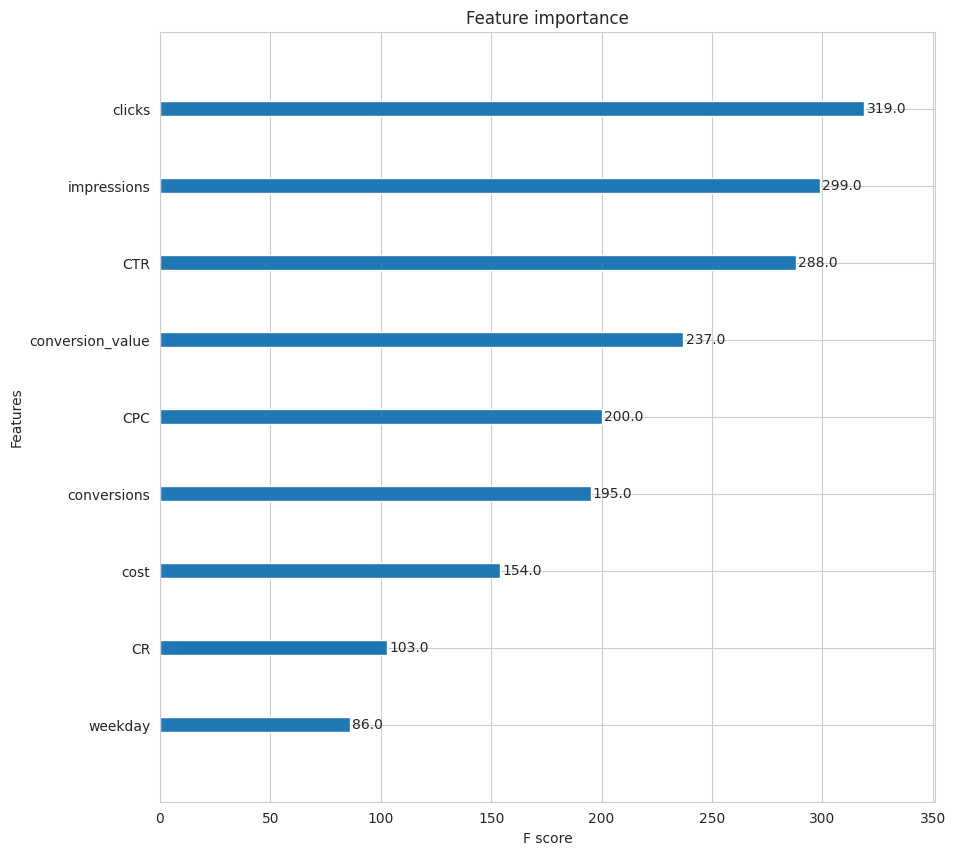

In [ ]:
# Plot feature importance
xgb.plot_importance(xgb_reg)
plt.show()

**2- XGboost Regressor + Balanced dataset**

The imblearn library was utilized to perform oversampling using the Synthetic Minority Oversampling Technique (SMOTE). SMOTE is a popular technique for addressing class imbalance, which generates synthetic samples for the minority class by interpolating between existing minority samples.

https://imbalanced-learn.org/stable/index.html

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

def handle_imbalance(X, y):
  # Print class distribution before oversampling
  print("Class distribution before oversampling:", Counter(y))

  # Apply oversampling
  oversampler = SMOTE()
  X_resampled, y_resampled = oversampler.fit_resample(X, y)

  # Print class distribution after oversampling
  print("Class distribution after oversampling:", Counter(y_resampled))

  return X_resampled, y_resampled

Class distribution before oversampling: Counter({3: 189, 4: 137, 2: 50, 5: 12, 1: 6})
Class distribution after oversampling: Counter({4: 189, 3: 189, 2: 189, 5: 189, 1: 189})


<Axes: xlabel='clicks', ylabel='impressions'>

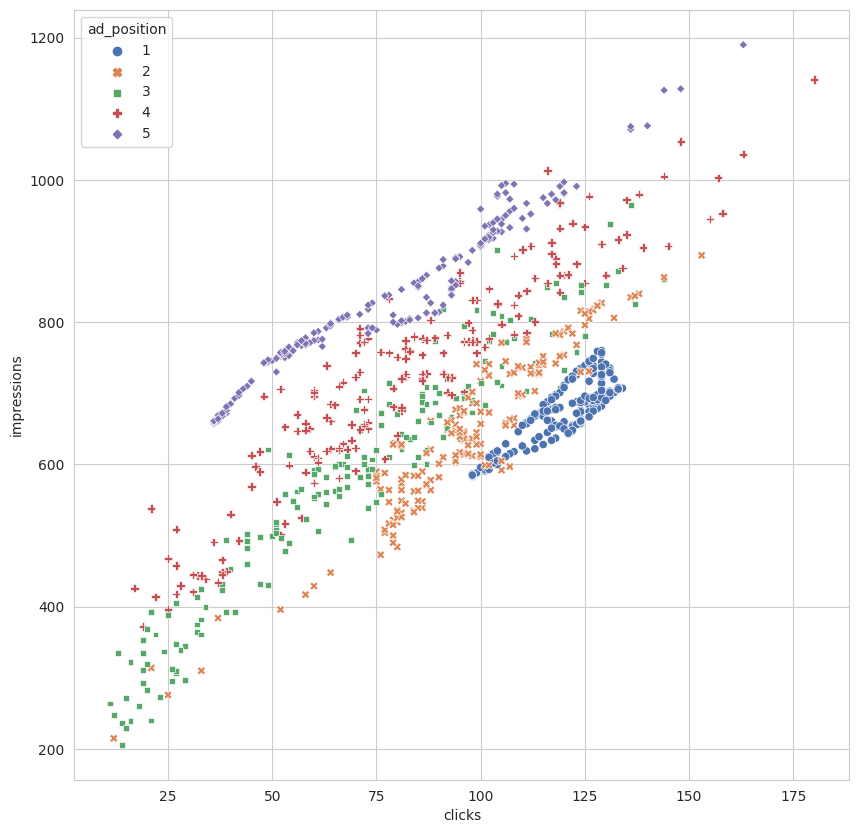

In [ ]:
X_resampled, y_resampled = handle_imbalance(X, y)
sns.scatterplot(x=X_resampled.clicks, y =X_resampled.impressions, hue = y_resampled, palette="deep", style = y_resampled)

Class distribution before oversampling: Counter({3: 189, 4: 137, 2: 50, 5: 12, 1: 6})
Class distribution after oversampling: Counter({4: 189, 3: 189, 2: 189, 5: 189, 1: 189})


<Axes: xlabel='impressions', ylabel='clicks'>

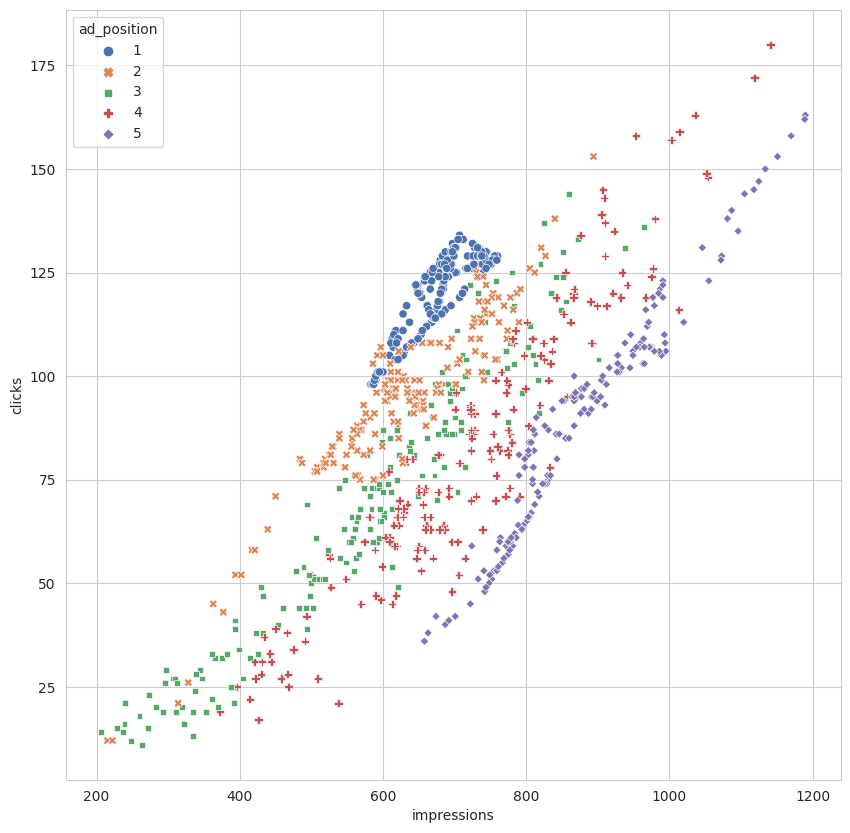

In [ ]:
X_resampled, y_resampled = handle_imbalance(X, y)
sns.scatterplot(x=X_resampled.impressions, y =X_resampled.clicks, hue = y_resampled, palette="deep", style = y_resampled)

In [ ]:
X_train_os, X_test_os, y_train_os, y_test_os = train_test_split(X_resampled, y_resampled, test_size = 0.3, random_state = 0)

In [ ]:
# Perform grid search with cross-validation
grid_search_os = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, cv=3)
grid_search.fit(X_train_os, y_train_os)

# Get the best hyperparameters
best_params_os = grid_search.best_params_

# Build and train the XGBoost regressor model
xgb_reg_os = xgb.XGBRegressor(**best_params)
scores_os = cross_val_score(xgb_reg_os, X_train_os, y_train_os, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)

scores_os = np.absolute(scores)
print('Mean MAE: %.3f (%.3f)' % (scores.mean(), scores.std()) )

Mean MAE: 0.125 (0.033)


In [ ]:
xgb_reg_os.fit(X_train_os, y_train_os)

# Predict ad positions for test data
y_pred_os = xgb_reg_os.predict(X_test_os)

# Round the predictions to the nearest integer (ad position)
y_pred_rounded_os = [int(round(pred)) for pred in y_pred_os]

# Calculate accuracy of the model
accuracy_os = accuracy_score(y_test_os, y_pred_rounded_os)
print("Accuracy:", accuracy_os)

Accuracy: 0.9330985915492958


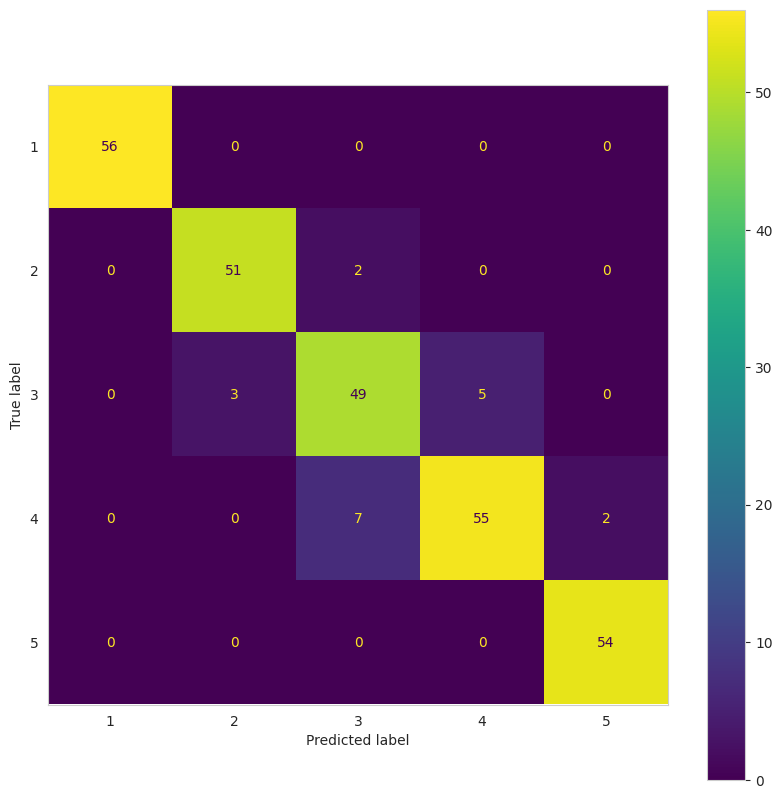

In [ ]:
cm_os = confusion_matrix(y_test_os, y_pred_rounded_os)
disp_os = ConfusionMatrixDisplay(cm_os, display_labels = ['1', '2', '3', '4', '5'])
disp_os.plot()
mpl.rcParams.update({})
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test_os,y_pred_rounded_os))

print('f1 score for each class', f1_score(y_test_os, y_pred_rounded_os, average=None))
print('macro', f1_score(y_test_os, y_pred_rounded_os, average='macro'))
print('weighted', f1_score(y_test_os, y_pred_rounded_os, average='weighted'))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        56
           2       0.94      0.96      0.95        53
           3       0.84      0.86      0.85        57
           4       0.92      0.86      0.89        64
           5       0.96      1.00      0.98        54

    accuracy                           0.93       284
   macro avg       0.93      0.94      0.93       284
weighted avg       0.93      0.93      0.93       284

f1 score for each class [1.         0.95327103 0.85217391 0.88709677 0.98181818]
macro 0.9348719794185183
weighted 0.9327100454085511


check how model can generalize on new data

In [ ]:
X.describe()

,clicks,impressions,cost,conversions,conversion_value,weekday,CRT,CR,CPC
count,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000
mean,77.738579,642.540609,50.346394,1.477056,66.815508,3.015228,0.116124,0.021036,0.612531
std,33.445108,173.373428,31.096362,1.475566,71.132970,1.994846,0.030795,0.027114,0.233213
min,11.000000,206.000000,2.850000,0.000000,0.000000,0.000000,0.038806,0.000000,0.223684
25%,56.000000,550.000000,28.700000,0.442500,13.570000,1.000000,0.094938,0.006945,0.423260
50%,79.500000,650.500000,46.855000,1.145000,45.275000,3.000000,0.118911,0.015179,0.581322
75%,100.000000,758.000000,67.092500,2.087500,95.835000,5.000000,0.139362,0.026477,0.749672
max,180.000000,1190.000000,156.650000,15.040000,410.400000,6.000000,0.189533,0.306939,1.438723


In [ ]:
column_ranges = X.describe().loc[['min', 'max']]
column_ranges

,clicks,impressions,cost,conversions,conversion_value,weekday,CRT,CR,CPC
min,11.0,206.0,2.85,0.00,0.0,0.0,0.038806,0.000000,0.223684
max,180.0,1190.0,156.65,15.04,410.4,6.0,0.189533,0.306939,1.438723


In [ ]:
y.describe()

count    394.000000
mean       3.251269
std        0.771840
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: ad_position, dtype: float64

In [ ]:
y_pred_w = xgb_reg_os.predict(X)

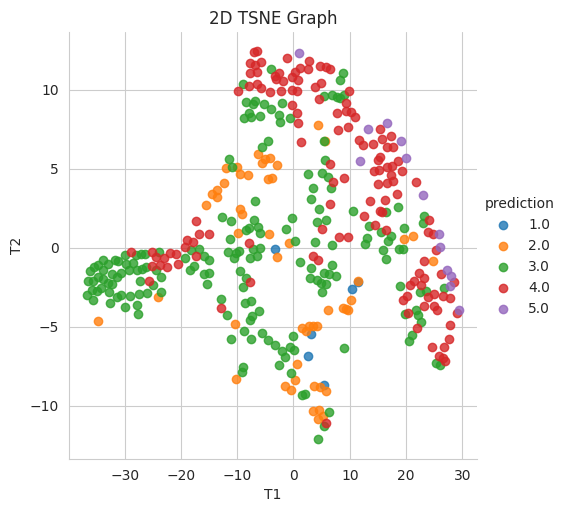

In [ ]:
tsne_ = TSNE()
tsne_features = tsne.fit_transform(X)
# sns.scatterplot(x=tsne_features[:, 0], y =tsne_features[:, 1], hue = np.rint(y_pred_w), palette="deep", style = np.rint(y_pred_w))
# plt.show()

tsne_df = pd.DataFrame(
    data=tsne_features,
    columns=['T1', 'T2'])

tsne_df['prediction'] = np.rint(y_pred_w)
tsne_df['ad_position'] = y

sns.lmplot(x='T1', y='T2', data=tsne_df, hue='prediction', fit_reg=False, legend=True)
plt.title('2D TSNE Graph')
plt.show()
# fig, axes = plt.subplots(1, 2, sharex=True)
# axes[0].set_title('Predicted')
# sns.lmplot(x='T1', y='T2', data=tsne_df, hue='prediction', fit_reg=False, legend=True)
# axes[1].set_title('True')
# sns.lmplot(x='T1', y='T2', data=tsne_df, hue='ad_position', fit_reg=False, legend=True)

# fig.suptitle('2D TSNE Graph')

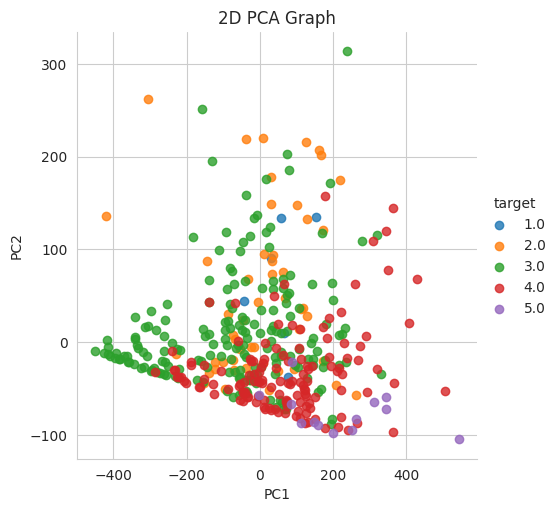

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X)

# Create dataframe
pca_df = pd.DataFrame(
    data=pca_features,
    columns=['PC1', 'PC2'])

pca_df['target'] = np.rint(y_pred_w)

sns.lmplot(
    x='PC1',
    y='PC2',
    data=pca_df,
    hue='target',
    fit_reg=False,
    legend=True
    )

plt.title('2D PCA Graph')
plt.show()

In [ ]:
novel = {'clicks':[1000, 200, 300, 5, 0],
         'impressions':[5000, 1500, 2000, 150, 0],
         'cost':[500, 200, 300, 1.5, 0],
         'conversions':[50, 20, 30, 0, 0],
         'conversion_value':[1000, 500, 600, 0, 0],
         'weekday':[1, 5, 4, 3, 0],
         'CRT':[0.2, 0.13, 0.15, 0.03, 0],
         'CR':[0.05, 0.1, 0.1, 0, 0],
         'CPC':[0.5, 1, 1, 0.3, 0]}

x_novel = pd.DataFrame(novel)
x_novel

,clicks,impressions,cost,conversions,conversion_value,weekday,CRT,CR,CPC
0,1000,5000,500.0,50,1000,1,0.20,0.05,0.5
1,200,1500,200.0,20,500,5,0.13,0.10,1.0
2,300,2000,300.0,30,600,4,0.15,0.10,1.0
3,5,150,1.5,0,0,3,0.03,0.00,0.3
4,0,0,0.0,0,0,0,0.00,0.00,0.0


In [ ]:
y_novel_pred = xgb_reg_os.predict(x_novel)
print(y_novel_pred)
[int(round(pred)) for pred in y_novel_pred]

[2.3832903 2.338794  2.3109248 2.8718674 3.0392492]


[2, 2, 2, 3, 3]

**AutoML with Pycaret**

to quickly check the performance of other regression models and compare them with our model, I used pycaret library which is very fast and handly to use.

In [ ]:
!pip install --upgrade pycaret
IPython.display.clear_output()

In [ ]:
from pycaret.regression import *
reg_model = setup(data=X_train, target=y_train, fold=3, session_id=123, verbose=False)
best_reg_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.2677,0.0986,0.3139,0.8363,0.0793,0.0901,0.1833
br,Bayesian Ridge,0.2680,0.0990,0.3146,0.8357,0.0789,0.0897,0.0867
en,Elastic Net,0.2704,0.1021,0.3195,0.8307,0.0800,0.0906,0.1433
lr,Linear Regression,0.2749,0.1040,0.3223,0.8277,0.0815,0.0929,2.3800
lar,Least Angle Regression,0.2749,0.1040,0.3223,0.8277,0.0815,0.0929,0.1133
lasso,Lasso Regression,0.2737,0.1059,0.3254,0.8244,0.0816,0.0919,0.1767
llar,Lasso Least Angle Regression,0.2737,0.1059,0.3254,0.8244,0.0816,0.0919,0.0867
gbr,Gradient Boosting Regressor,0.2922,0.1331,0.3638,0.7815,0.0880,0.0956,0.4767
huber,Huber Regressor,0.3202,0.1551,0.3899,0.7384,0.0986,0.1074,0.1867
rf,Random Forest Regressor,0.3116,0.1608,0.4007,0.7343,0.0971,0.1028,0.6900


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
evaluate_model(best_reg_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Predict ad positions for test data
y_pred_reg = predict_model(best_reg_model, data = X_test)

# Round the predictions to the nearest integer (ad position)
y_pred_reg_rounded = y_pred_reg['prediction_label'].round()

# Calculate accuracy
accuracy_reg = accuracy_score(y_test, y_pred_reg_rounded)
print("Accuracy:", accuracy_reg)

Accuracy: 0.957983193277311


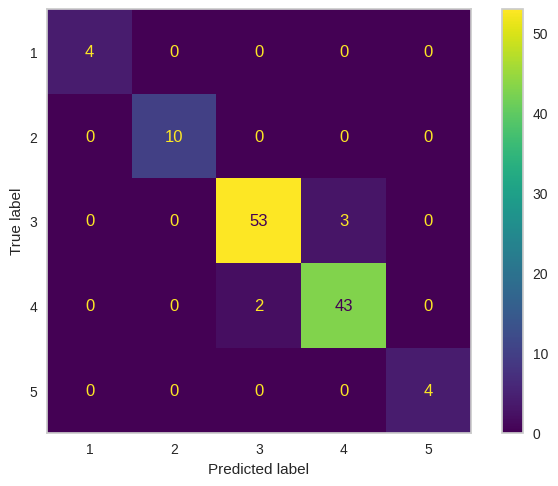

In [ ]:
cm_reg = confusion_matrix(y_test, y_pred_reg_rounded)
disp_reg = ConfusionMatrixDisplay(cm_reg, display_labels = ['1', '2', '3', '4', '5'])
disp_reg.plot()
mpl.rcParams.update({})
plt.grid(False)
plt.show()

In [ ]:
print(f1_score(y_test, y_pred_reg_rounded, average=None))
print(f1_score(y_test, y_pred_reg_rounded, average='macro'))
print(f1_score(y_test, y_pred_reg_rounded, average='weighted'))

[1.         1.         0.95495495 0.94505495 1.        ]
0.98000198000198
0.9580247899575629


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_reg_rounded))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00        10
           3       0.96      0.95      0.95        56
           4       0.93      0.96      0.95        45
           5       1.00      1.00      1.00         4

    accuracy                           0.96       119
   macro avg       0.98      0.98      0.98       119
weighted avg       0.96      0.96      0.96       119



**Next Steps:**
We can evaluate the performance of the statistical ordinal regressor models as mentioned earlier. Furthermore, it's important to note that the oversampling technique used was primarily aimed at addressing imbalanced data in classification problems. However, for imbalanced data in regression tasks, there are several techniques available that can be utilized to handle this issue effectively.

https://towardsdatascience.com/strategies-and-tactics-for-regression-on-imbalanced-data-61eeb0921fca

https://neptune.ai/blog/how-to-deal-with-imbalanced-classification-and-regression-data

